# Inventory System


      SINGLE-PRODUCT INVENTORY SYSTEM
Policy (s, S)          : (20, 40)
Time Length            : 120 months
----------------------------------------
Avg Ordering Cost      :      97.86
Avg Holding Cost       :       9.23
Avg Shortage Cost      :      18.79
----------------------------------------
TOTAL AVG MONTHLY COST :     125.88



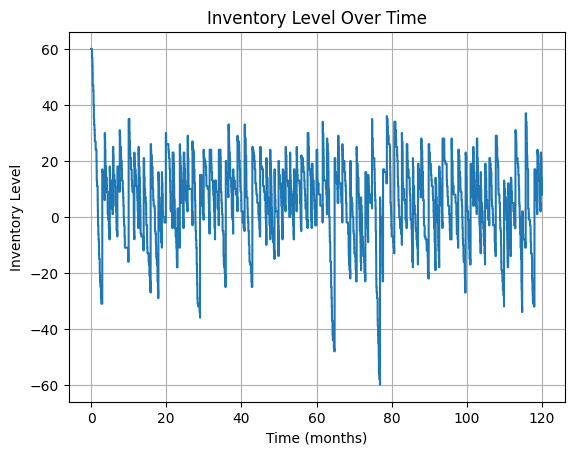

In [1]:
import math
import random
import matplotlib.pyplot as plt

# --- MODEL CONFIGURATION (Based on Law's Example) ---
MN_LEVEL = 20   # s
MX_LEVEL = 40   # S

INITIAL_INV_LEVEL = 60
NUM_MONTHS = 120

# Costs
SETUP_COST = 32.0
INCREMENTAL_COST = 3.0
HOLDING_COST = 1.0
SHORTAGE_COST = 5.0

# Distributions
MEAN_INTERDEMAND = 0.1  # Mean time between demands (months)
MIN_LAG = 0.5           # Min delivery lag (months)
MAX_LAG = 1.0           # Max delivery lag (months)

# --- GLOBAL STATE VARIABLES ---
sim_time = 0.0
inv_level = 0
time_last_event = 0.0

# Statistical Accumulators
total_ordering_cost = 0.0
area_holding = 0.0
area_shortage = 0.0
time_level = [] # (time, inventory level) pairs for plotting

# Event List
# 1: Order Arrival
# 2: Demand
# 3: Inventory Evaluation (Periodic)
# 4: End Simulation
time_next_event = [0.0] * 5
next_event_type = 0

def initialize():
    """Initialize the simulation state."""
    global sim_time, inv_level, time_last_event, total_ordering_cost
    global area_holding, area_shortage, time_next_event

    sim_time = 0.0
    inv_level = INITIAL_INV_LEVEL
    time_last_event = 0.0

    total_ordering_cost = 0.0
    area_holding = 0.0
    area_shortage = 0.0

    # Schedule initial events
    time_next_event[1] = 1.0e30  # No order arriving initially (Infinity)
    time_next_event[2] = sim_time + expon(MEAN_INTERDEMAND) # First demand
    time_next_event[3] = 0.0     # First inventory evaluation happens at t=0
    time_next_event[4] = float(NUM_MONTHS) # End of simulation

def timing():
    """Determines the next event type and advances the clock."""
    global sim_time, next_event_type

    min_time_next_event = 1.0e29
    next_event_type = 0

    # Determine the event type with the minimum time
    for i in range(1, 5):
        if time_next_event[i] < min_time_next_event:
            min_time_next_event = time_next_event[i]
            next_event_type = i

    if next_event_type == 0:
        print(f"Event list empty at time {sim_time}")
        sys.exit(1)

    # Advance the simulation clock
    sim_time = min_time_next_event

def update_time_avg_stats():
    global area_holding, area_shortage, time_last_event

    time_since_last_event = sim_time - time_last_event
    time_last_event = sim_time

    # Calculate area for holding (if inventory > 0) or shortage (if inventory < 0)
    if inv_level > 0:
        area_holding += inv_level * time_since_last_event
    elif inv_level < 0:
        area_shortage += -inv_level * time_since_last_event

def order_arrival():
    global inv_level, time_next_event
    inv_level += amount
    time_next_event[1] = 1.0e30

def demand():
    global inv_level, time_next_event
    demand_size = random_integer_demand()
    inv_level -= demand_size
    time_next_event[2] = sim_time + expon(MEAN_INTERDEMAND)

def evaluate():
    global inv_level, total_ordering_cost, amount, time_next_event
    if inv_level < MN_LEVEL:
        amount = MX_LEVEL - inv_level
        total_ordering_cost += SETUP_COST + (INCREMENTAL_COST * amount)
        time_next_event[1] = sim_time + uniform(MIN_LAG, MAX_LAG)

    time_next_event[3] = sim_time + 1.0

def report():
    avg_ordering_cost = total_ordering_cost / NUM_MONTHS
    avg_holding_cost = (HOLDING_COST * area_holding) / NUM_MONTHS
    avg_shortage_cost = (SHORTAGE_COST * area_shortage) / NUM_MONTHS
    
    total_avg_cost = avg_ordering_cost + avg_holding_cost + avg_shortage_cost

    print("\n" + "=" * 40)
    print("      SINGLE-PRODUCT INVENTORY SYSTEM")
    print("=" * 40)
    print(f"Policy (s, S)          : ({MN_LEVEL}, {MX_LEVEL})")
    print(f"Time Length            : {NUM_MONTHS} months")
    print("-" * 40)
    print(f"Avg Ordering Cost      : {avg_ordering_cost:10.2f}")
    print(f"Avg Holding Cost       : {avg_holding_cost:10.2f}")
    print(f"Avg Shortage Cost      : {avg_shortage_cost:10.2f}")
    print("-" * 40)
    print(f"TOTAL AVG MONTHLY COST : {total_avg_cost:10.2f}")
    print("=" * 40 + "\n")

# --- HELPER FUNCTIONS (Random Variate Generators) ---

def expon(mean):
    """Returns an exponential random variate with mean 'mean'."""
    return -mean * math.log(random.random())

def uniform(a, b):
    """Returns a uniform random variate between a and b."""
    return a + random.random() * (b - a)

def random_integer_demand():
    """
    1 w.p. 1/6, 2 w.p. 1/3, 3 w.p. 1/3, 4 w.p. 1/6
    """
    u = random.random()
    if u < 0.16667:
        return 1
    elif u < 0.5:
        return 2
    elif u < 0.83333:
        return 3
    else:
        return 4

def plot_inventory_level():
    times, levels = zip(*time_level)
    plt.step(times, levels, where='post')
    plt.xlabel('Time (months)')
    plt.ylabel('Inventory Level')
    plt.title('Inventory Level Over Time')
    plt.grid()
    plt.show()

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    initialize()
    while True:
        timing()
        update_time_avg_stats()
        time_level.append((sim_time, inv_level))

        if next_event_type == 1:
            order_arrival()
        elif next_event_type == 2:
            demand()
        elif next_event_type == 3:
            evaluate()
        elif next_event_type == 4:
            report()
            break  

    plot_inventory_level()